In [41]:

# Customer Churn Prediction using Artificial Neural Networks

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Neural Network
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

In [14]:
# Load dataset
df = pd.read_csv("Telco Customer Churn dataset.csv")

# Display first five rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
# Shape of dataset
print("Dataset Shape:", df.shape)

print("\n")

# Dataset information
df.info()

print("\n")

# Missing values
print(df.isnull().sum())

print("\n")

# Target distribution
print(df["Churn"].value_counts())

Dataset Shape: (7043, 21)


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 no

In [9]:
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [11]:
# Replace blank spaces with NaN
df = df.replace(" ", np.nan)

# Check missing values again
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [16]:
# CustomerID is not useful
df.drop("customerID", axis=1, inplace=True)

# TotalCharges contains blank strings
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Remove missing rows
df.dropna(inplace=True)

print(df.shape)

(7032, 20)


In [24]:
from sklearn.preprocessing import LabelEncoder

# Encode every categorical column
label_encoders = {}

categorical_columns = df.select_dtypes(include=["object"]).columns

for column in categorical_columns:
    encoder = LabelEncoder()
    df[column] = encoder.fit_transform(df[column])
    label_encoders[column] = encoder

print(df.dtypes)

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


In [28]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(5625, 19)
(1407, 19)


In [32]:
model_and = Sequential([
    Dense(1, activation="sigmoid", input_shape=(2,))
])

model_and.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

X_and = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_and = np.array([0,0,0,1])

model_and.fit(
    X_and,
    y_and,
    epochs=500,
    verbose=0
)

print(np.round(model_and.predict(X_and)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
[[0.]
 [1.]
 [0.]
 [0.]]


In [33]:
model_or = Sequential([
    Dense(1, activation="sigmoid", input_shape=(2,))
])

model_or.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

y_or = np.array([0,1,1,1])

model_or.fit(
    X_and,
    y_or,
    epochs=500,
    verbose=0
)

print(np.round(model_or.predict(X_and)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
[[1.]
 [0.]
 [1.]
 [1.]]


In [34]:
model_not = Sequential([
    Dense(1, activation="sigmoid", input_shape=(1,))
])

model_not.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

X_not = np.array([
    [0],
    [1]
])

y_not = np.array([1,0])

model_not.fit(
    X_not,
    y_not,
    epochs=500,
    verbose=0
)

print(np.round(model_not.predict(X_not)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
[[1.]
 [0.]]


In [35]:
model_xor = Sequential([
    Dense(4, activation="relu", input_shape=(2,)),
    Dense(1, activation="sigmoid")
])

model_xor.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

y_xor = np.array([0,1,1,0])

model_xor.fit(
    X_and,
    y_xor,
    epochs=1000,
    verbose=0
)

print(np.round(model_xor.predict(X_and)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
[[0.]
 [1.]
 [1.]
 [0.]]


In [36]:
model = Sequential()

model.add(Dense(
    32,
    activation="relu",
    input_shape=(X_train.shape[1],)
))

model.add(Dense(
    16,
    activation="relu"
))

model.add(Dense(
    1,
    activation="sigmoid"
))

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 822us/step - accuracy: 0.7484 - loss: 0.5074 - val_accuracy: 0.7902 - val_loss: 0.4313
Epoch 2/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 347us/step - accuracy: 0.7856 - loss: 0.4388 - val_accuracy: 0.8080 - val_loss: 0.4141
Epoch 3/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 341us/step - accuracy: 0.7973 - loss: 0.4266 - val_accuracy: 0.8000 - val_loss: 0.4103
Epoch 4/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 334us/step - accuracy: 0.8018 - loss: 0.4198 - val_accuracy: 0.8080 - val_loss: 0.4075
Epoch 5/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 336us/step - accuracy: 0.8067 - loss: 0.4144 - val_accuracy: 0.8053 - val_loss: 0.4069
Epoch 6/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 335us/step - accuracy: 0.8073 - loss: 0.4109 - val_accuracy: 0.8098 - val_loss: 0.4062
Epoch 7/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 338us/step - accuracy: 0.8084 - loss: 0.4067 - val_accuracy: 0.8080 - val_loss: 0.4061
Epoch 8/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 335us/step - accuracy: 0.8102 - loss: 0.4049 - 

In [45]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 32)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,557 (13.90 KB)

 Trainable params: 1,185 (4.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,372 (9.27 KB)

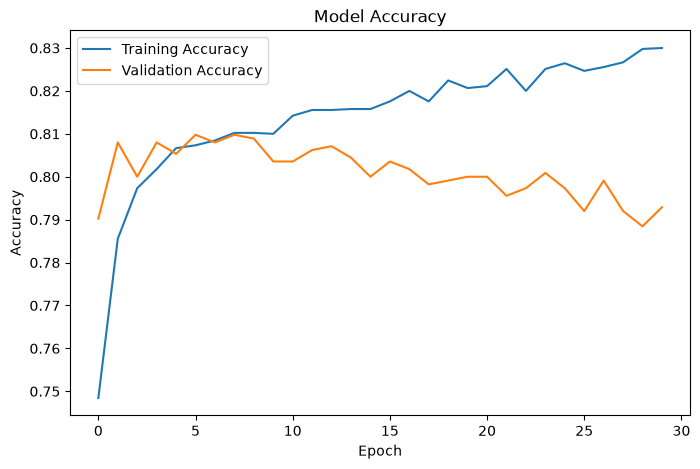

In [37]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")

plt.legend()

plt.show()

In [38]:
predictions = model.predict(X_test)

predictions = (predictions > 0.5).astype(int)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 487us/step


In [39]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.7882018479033405


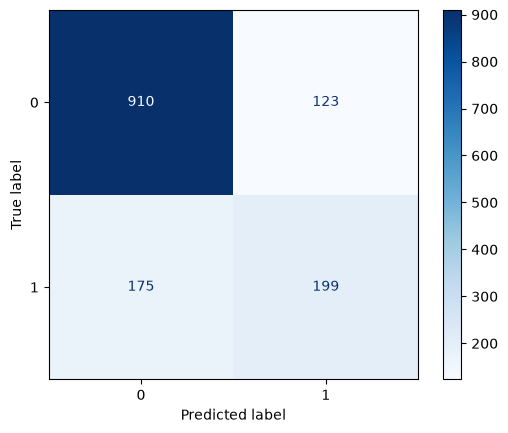

In [42]:
cm = confusion_matrix(
    y_test,
    predictions
)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap="Blues")

plt.show()

In [43]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.62      0.53      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.78      1407



In [44]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions.flatten()
})

print(results.head(20))

    Actual  Predicted
0        0          0
1        0          0
2        1          1
3        0          0
4        0          0
5        0          1
6        0          0
7        0          1
8        0          0
9        0          0
10       0          0
11       1          0
12       0          0
13       0          0
14       0          0
15       0          0
16       1          1
17       0          0
18       1          0
19       1          0


In [46]:
accuracy = accuracy_score(y_test, predictions)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.7882
